# **Exaustive machine learning project (housing prices) : exploration and predictions**


1. Load and Explore the Dataset
- Loading and basic exploration of the dataset
- First descriptive statistics of the dataset
- Selection and justification of the variable choice for the parts below in 4 distinct data structures isolating up to 10 variables for each method to be used (**Clust1**, **Clust2**, **Reg1**, **Reg2**)

In [187]:
pip install optuna

In [188]:
import pandas as pd
from math import nan
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import ElasticNetCV
from sklearn.neighbors import KNeighborsRegressor

from sklearn.decomposition import PCA

import optuna

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


In [189]:
df = pd.read_csv('train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [190]:
X_final_test_before_cleaning = pd.read_csv('test.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [268]:
id_serie = X_final_test_before_cleaning.Id

In [191]:
df = pd.concat([df, X_final_test_before_cleaning], axis = 0)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


In [192]:
def get_best_regression_degree(data_X, data_y, model, range=range(1, 100)):
  scores = pd.Series(index=range)
  for d in range :
    print('\n degree in process : ', d)
    polynomial_converter = PolynomialFeatures(degree=d, include_bias=False)
    poly_data_X = polynomial_converter.fit_transform(data_X)
    print('number of features : ', np.shape(poly_data_X)[1])
    score = cross_val_score(model, poly_data_X, data_y, cv=5, scoring='neg_mean_absolute_percentage_error').mean()
    scores[d]=score
    print('mean_absolute_percentage_error (mean CV): ', -score)
    model.fit(poly_data_X, data_y)
    print('mean_absolute_percentage_error (on the training set) : ', mean_absolute_percentage_error(data_y, model.predict(poly_data_X)))

  return np.argmax(scores), np.max(score)

# **Data Cleaning**

In this section, we
- put the features into the right data structure
- deal with missing values (replace or drop)
- Data Preparation : create different versions of the dataset to apply the models flexibly later (X_train, X_test, y_train, y_test, scaled features, only numerical features, etc)

***useful quality dict***

In [193]:
Qual_dict = {
    'Po' : 0,
    'Fa' : 1,
    'TA' : 2,
    'Gd' : 3,
    'Ex' : 4
}

## num to cat

**MSSubClass** : Num to Cat

This variable identifies the type of dwelling involved in the sale.

In [194]:
df.MSSubClass.value_counts()

,count
MSSubClass,
20,1079
60,575
50,287
120,182
30,139
70,128
160,128
80,118
90,109


In [195]:
MSSubClass_dict =  {20  :  '1-STORY 1946 & NEWER ALL STYLES',
                    30  :  '1-STORY 1945 & OLDER',
                    40  :  '1-STORY W/FINISHED ATTIC ALL AGES',
                    45  :  '1-1/2 STORY - UNFINISHED ALL AGES',
                    50  :  '1-1/2 STORY FINISHED ALL AGES',
                    60  :  '2-STORY 1946 & NEWER',
                    70  :  '2-STORY 1945 & OLDER',
                    75  :  '2-1/2 STORY ALL AGES',
                    80  :  'SPLIT OR MULTI-LEVEL',
                    85  :  'SPLIT FOYER',
                    90  :  'DUPLEX - ALL STYLES AND AGES',
                    120  :  '1-STORY PUD (Planned Unit Development) - 1946 & NEWER',
                    150  :  '1-1/2 STORY PUD - ALL AGES',
                    160  :  '2-STORY PUD - 1946 & NEWER',
                    180  :  'PUD - MULTILEVEL - INCL SPLIT LEV/FOYER',
                    190  :  '2 FAMILY CONVERSION - ALL STYLES AND AGES'
                    }

df['MSSubClass'] = df['MSSubClass'].apply(lambda n: MSSubClass_dict[n])
df.MSSubClass.value_counts()

,count
MSSubClass,
1-STORY 1946 & NEWER ALL STYLES,1079
2-STORY 1946 & NEWER,575
1-1/2 STORY FINISHED ALL AGES,287
1-STORY PUD (Planned Unit Development) - 1946 & NEWER,182
1-STORY 1945 & OLDER,139
2-STORY 1945 & OLDER,128
2-STORY PUD - 1946 & NEWER,128
SPLIT OR MULTI-LEVEL,118
DUPLEX - ALL STYLES AND AGES,109


In [196]:
# MSSubClass_dict =  {20  :  'A',
#                     30  :  'B',
#                     40  :  'C',
#                     45  :  'D',
#                     50  :  'E',
#                     60  :  'F',
#                     70  :  'G',
#                     75  :  'H',
#                     80  :  'I',
#                     85  :  'J',
#                     90  :  'K',
#                     120  :  'L',
#                     150  :  'M',
#                     160  :  'N',
#                     180  :  'O',
#                     190  :  'P'
#                     }

# df['MSSubClass'] = df['MSSubClass'].apply(lambda n: MSSubClass_dict[n])
# df.MSSubClass.value_counts()

## cat to bin

**Street** : Cat to Bin

This variable represents the type of road access to property (material)

In [197]:
df.Street.value_counts()

,count
Street,
Pave,2907
Grvl,12


In [198]:
df.Street = df.Street.apply(lambda a: 0 if a=='Pave' else 1)
df.Street.value_counts()

,count
Street,
0,2907
1,12


Type of alley access to property (material)

In [199]:
df.Alley.value_counts()

,count
Alley,
Grvl,120
Pave,78


In [200]:
df.Alley = df.Alley.fillna('NA')
df.Alley.value_counts()

,count
Alley,
NA,2721
Grvl,120
Pave,78


**CentralAir** : Cat to Bin

This variable represents central air conditioning

In [201]:
df.CentralAir.value_counts()

,count
CentralAir,
Y,2723
N,196


In [202]:
df['CentralAir'] = df['CentralAir'].apply(lambda a: 0 if a=='N' else 1)
df.CentralAir.value_counts()

,count
CentralAir,
1,2723
0,196


## cat to num

**LotShape** : name change (from LotShape to LotIrregularity)

**LotIrregularity** : Cat to Num

In [203]:
df.LotShape.value_counts()

,count
LotShape,
Reg,1859
IR1,968
IR2,76
IR3,16


In [204]:
LotShape_dict = {
    'Reg' : 0,
    'IR1' : 1,
    'IR2' : 2,
    'IR3' : 3
}

df['LotIrregularity'] = df.LotShape.apply(lambda a: LotShape_dict[a])
df.drop('LotShape', axis=1)
df = df.drop('LotShape', axis=1)
df['LotIrregularity'].value_counts()

,count
LotIrregularity,
0,1859
1,968
2,76
3,16


**LandSlope** : Cat to Num

In [205]:
df.LandSlope.value_counts()

,count
LandSlope,
Gtl,2778
Mod,125
Sev,16


In [206]:
LandSlope_dict = {
    'Gtl' : 1,
    'Mod' : 2,
    'Sev' : 3
}

df['LandSlope'] = df.LandSlope.apply(lambda a: LandSlope_dict[a])
df['LandSlope'].value_counts()

,count
LandSlope,
1,2778
2,125
3,16


**ExterQual** : Cat to Num

In [207]:
df.ExterQual.value_counts()

,count
ExterQual,
TA,1798
Gd,979
Ex,107
Fa,35


In [208]:
df['ExterQual'] = df['ExterQual'].apply(lambda a: Qual_dict[a] if type(a)==str else nan)
df.ExterQual.value_counts()

,count
ExterQual,
2,1798
3,979
4,107
1,35


**ExterCond** : Cat to Num

In [209]:
df.ExterCond.value_counts()

,count
ExterCond,
TA,2538
Gd,299
Fa,67
Ex,12
Po,3


In [210]:
df['ExterCond'] = df['ExterCond'].apply(lambda a: Qual_dict[a] if type(a)==str else nan)
df.ExterCond.value_counts()

,count
ExterCond,
2,2538
3,299
1,67
4,12
0,3


**HeatingQC** : Cat to Num

In [211]:
df.HeatingQC.value_counts()

,count
HeatingQC,
Ex,1493
TA,857
Gd,474
Fa,92
Po,3


In [212]:
df['HeatingQC'] = df['HeatingQC'].apply(lambda a: Qual_dict[a] if type(a)==str else nan)
df.HeatingQC.value_counts()

,count
HeatingQC,
4,1493
2,857
3,474
1,92
0,3


**KitchenQual** : Cat to Num

In [213]:
df.KitchenQual.value_counts()

,count
KitchenQual,
TA,1492
Gd,1151
Ex,205
Fa,70


In [214]:
df['KitchenQual'] = df['KitchenQual'].apply(lambda a: Qual_dict[a] if type(a)==str else nan)
df.KitchenQual.value_counts()

,count
KitchenQual,
2.0,1492
3.0,1151
4.0,205
1.0,70


**FireplaceQu** : Cat to Num

In [215]:
df.FireplaceQu.value_counts()

,count
FireplaceQu,
Gd,744
TA,592
Fa,74
Po,46
Ex,43


In [216]:
df['FireplaceQu'] = df['FireplaceQu'].apply(lambda a: Qual_dict[a] if type(a)==str else nan)
df['FireplaceQu'] = df['FireplaceQu'].fillna(-1)
df.FireplaceQu.value_counts()

,count
FireplaceQu,
-1.0,1420
3.0,744
2.0,592
1.0,74
0.0,46
4.0,43


## about basement

**BsmtQual** : Cat to Num

In [217]:
df.BsmtQual.value_counts()

,count
BsmtQual,
TA,1283
Gd,1209
Ex,258
Fa,88


In [218]:
df['BsmtQual'] = df['BsmtQual'].apply(lambda a: Qual_dict[a] if type(a)==str else nan)
df['BsmtQual'] = df['BsmtQual'].fillna(-1)
df.BsmtQual.value_counts()

,count
BsmtQual,
2.0,1283
3.0,1209
4.0,258
1.0,88
-1.0,81


**BsmtCond** : Cat to Num

In [219]:
df.BsmtCond.value_counts()

,count
BsmtCond,
TA,2606
Gd,122
Fa,104
Po,5


In [220]:
df['BsmtCond'] = df['BsmtCond'].apply(lambda a: Qual_dict[a] if type(a)==str else nan)
df['BsmtCond'] = df['BsmtCond'].fillna(-1)
df.BsmtCond.value_counts()

,count
BsmtCond,
2.0,2606
3.0,122
1.0,104
-1.0,82
0.0,5


**BsmtExposureExist** : variable created from BsmtExposure 'No' category

In [221]:
df.BsmtExposure.value_counts()

,count
BsmtExposure,
No,1904
Av,418
Gd,276
Mn,239


In [222]:
BsmtExposure_array = np.ones(len(df))
BsmtExposure_array[df[df['BsmtExposure']=='No'].index]=0
df['BsmtExposureExist']=BsmtExposure_array.astype(int)
df.BsmtExposureExist.value_counts()

,count
BsmtExposureExist,
1,1633
0,1286


**BsmtExist** : variable created from BsmtCond NaN's

In [223]:
BsmtExist_array = np.ones(len(df))
BsmtExist_array[df[df['BsmtFinType1'].isnull()].index]=0
df['BsmtExist']=BsmtExist_array.astype(int)
df.BsmtExist.value_counts()

,count
BsmtExist,
1,2840
0,79


**BsmtExposure** : Cat to Num

In [224]:
df.BsmtExposure.value_counts()

,count
BsmtExposure,
No,1904
Av,418
Gd,276
Mn,239


In [225]:
BsmtExposure_dict = {
    'Gd' : 3,
    'Av' : 2,
    'Mn' : 1,
    'No' : 0
}

df['BsmtExposure'] = df['BsmtExposure'].apply(lambda a: BsmtExposure_dict[a] if type(a)==str else nan)
df['BsmtExposure'] = df['BsmtExposure'].fillna(-1)
df.BsmtExposure.value_counts()

,count
BsmtExposure,
0.0,1904
2.0,418
3.0,276
1.0,239
-1.0,82


## about garage

**GarageFinish** : Cat to Num

In [226]:
df.GarageFinish.value_counts()

,count
GarageFinish,
Unf,1230
RFn,811
Fin,719


In [227]:
GarageFinish_dict = {
    'Unf' : 1,
    'RFn' : 2,
    'Fin' : 3
}

df['GarageFinish'] = df['GarageFinish'].apply(lambda a: GarageFinish_dict[a] if type(a)==str else -1)
df.GarageFinish.value_counts()

,count
GarageFinish,
1,1230
2,811
3,719
-1,159


**GarageQual** : Cat to Num

In [228]:
df.GarageQual.value_counts()

,count
GarageQual,
TA,2604
Fa,124
Gd,24
Po,5
Ex,3


In [229]:
GarageQual_dict = {
    'Po' : 0,
    'Fa' : 1,
    'TA' : 2,
    'Gd' : 3,
    'Ex' : 4
}

df['GarageQual'] = df['GarageQual'].apply(lambda a: GarageQual_dict[a] if type(a)==str else -1)
df.GarageQual.value_counts()

,count
GarageQual,
2,2604
-1,159
1,124
3,24
0,5
4,3


**GarageCond** : Cat to Num

In [230]:
df.GarageCond.value_counts()

,count
GarageCond,
TA,2654
Fa,74
Gd,15
Po,14
Ex,3


In [231]:
GarageCond_dict = {
    'Po' : 0,
    'Fa' : 1,
    'TA' : 2,
    'Gd' : 3,
    'Ex' : 4
}

df['GarageCond'] = df['GarageCond'].apply(lambda a: GarageCond_dict[a] if type(a)==str else -1)
df.GarageCond.value_counts()

,count
GarageCond,
2,2654
-1,159
1,74
3,15
0,14
4,3


**GarageExist** : variable created from GarageType NaN values

In [232]:
GarageExist_array = np.ones(len(df))
GarageExist_array[df[df['GarageType'].isnull()].index]=0
df['GarageExist']=GarageExist_array.astype(int)
df.GarageExist.value_counts()

,count
GarageExist,
1,2767
0,152


## about pool

**PoolExist** : variable created from PoolQC NaN values

In [233]:
PoolExist_array = np.ones(len(df))
PoolExist_array[df[df['PoolQC'].isnull()].index]=0
df['PoolExist']=PoolExist_array.astype(int)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotIrregularity,BsmtExposureExist,BsmtExist,GarageExist,PoolExist
0,1,2-STORY 1946 & NEWER,RL,65.0,8450,0,NA,Lvl,AllPub,Inside,1,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,3,2,PConc,3.0,2.0,0.0,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,4,1,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,3.0,8,Typ,0,-1.0,Attchd,2003.0,2,2.0,548.0,2,2,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0,0,0,1,1,0
1,2,1-STORY 1946 & NEWER ALL STYLES,RL,80.0,9600,0,NA,Lvl,AllPub,FR2,1,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,2,2,CBlock,3.0,2.0,3.0,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,4,1,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,2.0,6,Typ,1,2.0,Attchd,1976.0,2,2.0,460.0,2,2,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0,0,0,1,1,0
2,3,2-STORY 1946 & NEWER,RL,68.0,11250,0,NA,Lvl,AllPub,Inside,1,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,3,2,PConc,3.0,2.0,1.0,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,4,1,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,3.0,6,Typ,1,2.0,Attchd,2001.0,2,2.0,608.0,2,2,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0,1,0,1,1,0
3,4,2-STORY 1945 & OLDER,RL,60.0,9550,0,NA,Lvl,AllPub,Corner,1,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,2,2,BrkTil,2.0,3.0,0.0,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,3,1,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,3.0,7,Typ,1,3.0,Detchd,1998.0,1,3.0,642.0,2,2,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0,1,0,1,1,0
4,5,2-STORY 1946 & NEWER,RL,84.0,14260,0,NA,Lvl,AllPub,FR2,1,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,3,2,PConc,3.0,2.0,2.0,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,4,1,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,3.0,9,Typ,1,2.0,Attchd,2000.0,2,3.0,836.0,2,2,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0,1,0,1,1,0


**PoolQC** : Cat to Num

In [234]:
df.PoolQC.value_counts()

,count
PoolQC,
Ex,4
Gd,4
Fa,2


In [235]:
PoolQC_dict = {
    'Po' : 0,
    'Fa' : 1,
    'TA' : 2,
    'Gd' : 3,
    'Ex' : 4
}

df['PoolQC'] = df['PoolQC'].apply(lambda a: PoolQC_dict[a] if type(a)==str else -1)
df.PoolQC.value_counts()

,count
PoolQC,
-1,2909
4,4
3,4
1,2


## about fence

In [236]:
df.Fence.value_counts()

,count
Fence,
MnPrv,329
GdPrv,118
GdWo,112
MnWw,12


**FenceExist** :  variable created from Fence NaN values

In [237]:
FenceExist_array = np.ones(len(df))
FenceExist_array[df[df['Fence'].isnull()].index]=0
df['FenceExist']=FenceExist_array.astype(int)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotIrregularity,BsmtExposureExist,BsmtExist,GarageExist,PoolExist,FenceExist
0,1,2-STORY 1946 & NEWER,RL,65.0,8450,0,NA,Lvl,AllPub,Inside,1,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,3,2,PConc,3.0,2.0,0.0,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,4,1,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,3.0,8,Typ,0,-1.0,Attchd,2003.0,2,2.0,548.0,2,2,Y,0,61,0,0,0,0,-1,NaN,NaN,0,2,2008,WD,Normal,208500.0,0,0,1,1,0,0
1,2,1-STORY 1946 & NEWER ALL STYLES,RL,80.0,9600,0,NA,Lvl,AllPub,FR2,1,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,2,2,CBlock,3.0,2.0,3.0,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,4,1,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,2.0,6,Typ,1,2.0,Attchd,1976.0,2,2.0,460.0,2,2,Y,298,0,0,0,0,0,-1,NaN,NaN,0,5,2007,WD,Normal,181500.0,0,0,1,1,0,0
2,3,2-STORY 1946 & NEWER,RL,68.0,11250,0,NA,Lvl,AllPub,Inside,1,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,3,2,PConc,3.0,2.0,1.0,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,4,1,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,3.0,6,Typ,1,2.0,Attchd,2001.0,2,2.0,608.0,2,2,Y,0,42,0,0,0,0,-1,NaN,NaN,0,9,2008,WD,Normal,223500.0,1,0,1,1,0,0
3,4,2-STORY 1945 & OLDER,RL,60.0,9550,0,NA,Lvl,AllPub,Corner,1,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,2,2,BrkTil,2.0,3.0,0.0,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,3,1,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,3.0,7,Typ,1,3.0,Detchd,1998.0,1,3.0,642.0,2,2,Y,0,35,272,0,0,0,-1,NaN,NaN,0,2,2006,WD,Abnorml,140000.0,1,0,1,1,0,0
4,5,2-STORY 1946 & NEWER,RL,84.0,14260,0,NA,Lvl,AllPub,FR2,1,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,3,2,PConc,3.0,2.0,2.0,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,4,1,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,3.0,9,Typ,1,2.0,Attchd,2000.0,2,3.0,836.0,2,2,Y,192,84,0,0,0,0,-1,NaN,NaN,0,12,2008,WD,Normal,250000.0,1,0,1,1,0,0


## special cases

**LotFrontage** : NaN becomes 0 as a numerical value

The variable LotFrontage represent the linear feet of street connected to property

In [238]:
df.LotFrontage.isnull().sum()

486

In [239]:
df.LotFrontage = df.LotFrontage.fillna(0)
df.LotFrontage.isnull().sum()

0

**MasVnrType** : NaN becomes 'NA' as a category

In [240]:
df.MasVnrType.value_counts()

,count
MasVnrType,
BrkFace,879
Stone,249
BrkCmn,25


In [241]:
df.MasVnrType.isnull().sum()

1766

In [242]:
df.MasVnrType = df.MasVnrType.fillna('NA')
df.MasVnrType.isnull().sum()

0

In [243]:
df.MasVnrType.value_counts()

,count
MasVnrType,
NA,1766
BrkFace,879
Stone,249
BrkCmn,25


**Electric** : column number reduction

In [244]:
df.Electrical = df.Electrical.fillna('NA')
df.Electrical = df.Electrical.apply(lambda a: 'Other' if a in ['FuseP', 'Mix', 'NA'] else a)
df.Electrical.value_counts()

,count
Electrical,
SBrkr,2671
FuseA,188
FuseF,50
Other,10


**MasVnrArea** : null becomes 0 square feets

In [245]:
df.MasVnrArea = df.MasVnrArea.fillna(0)

**MiscFeature** : replace NaN by the category 'NA' (as no other feature is added)

In [246]:
df.MiscFeature = df.MiscFeature.fillna('NA')

## Data Preparation

We
- drop all remaining missing values so that our predictive models can train on the dataset
- create different all the different versions of the dataset to be able to play with them when we run predictive models
- Not very legal but thee will be leakage of final_test categories to train features (when applying get_dummies to train+test data at once)

We drop *GarageYrBlt* (garage year built) because :

1) it is very correlated to another variable named *YearBuilt*, witch is more relevant

2) it has too many missing values (when there is no garage), and missing values and hard to deal with in numerical features because they can not be created as a seperate class with one-hot encoding. Replacing missing values with an outlier like 0 could work but some models could have a bias interpreting 0 as a year (even though we had to use this method in previous data cleaning for important numerical features with missing values)

In [247]:
df = df.drop(['Id', 'GarageYrBlt'], axis=1)

In [248]:
df.isnull().sum()[df.isnull().sum()!=0]

,0
MSZoning,4
Utilities,2
Exterior1st,1
Exterior2nd,1
BsmtFinType1,79
BsmtFinSF1,1
BsmtFinType2,80
BsmtFinSF2,1
BsmtUnfSF,1
TotalBsmtSF,1


*BsmtFinType1* and *BsmtFinType2* have missing values that correspond to the category 0 in the feature *BsmtExist*. So there is no need to create a new binary feature for missing values during one-hot encoding as we already have it (*BsmtExist*)

The same for *GarageType* as we already have the *GarageExist* feature, and fence as we have *FenceExist* feature

In [249]:
len(df)

2919

In [250]:
# df.get_dummies
# split df : [X, y] + [X_final_test]
#  [X, y] to X_train, X_test, y_train, y_test

In [251]:
df = pd.get_dummies(df)

In [252]:
df.head()

,LotFrontage,LotArea,Street,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,MoSold,YrSold,SalePrice,LotIrregularity,BsmtExposureExist,BsmtExist,GarageExist,PoolExist,FenceExist,MSSubClass_1-1/2 STORY - UNFINISHED ALL AGES,MSSubClass_1-1/2 STORY FINISHED ALL AGES,MSSubClass_1-1/2 STORY PUD - ALL AGES,MSSubClass_1-STORY 1945 & OLDER,MSSubClass_1-STORY 1946 & NEWER ALL STYLES,MSSubClass_1-STORY PUD (Planned Unit Development) - 1946 & NEWER,MSSubClass_1-STORY W/FINISHED ATTIC ALL AGES,MSSubClass_2 FAMILY CONVERSION - ALL STYLES AND AGES,MSSubClass_2-1/2 STORY ALL AGES,MSSubClass_2-STORY 1945 & OLDER,MSSubClass_2-STORY 1946 & NEWER,MSSubClass_2-STORY PUD - 1946 & NEWER,MSSubClass_DUPLEX - ALL STYLES AND AGES,MSSubClass_PUD - MULTILEVEL - INCL SPLIT LEV/FOYER,MSSubClass_SPLIT FOYER,MSSubClass_SPLIT OR MULTI-LEVEL,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Alley_Grvl,Alley_NA,Alley_Pave,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub,Utilities_NoSeWa,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_ClyTile,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_NA,MasVnrType_Stone,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtFinType1_ALQ,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_ALQ,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,Electrical_FuseA,Electrical_FuseF,Electrical_Other,Electrical_SBrkr,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functio

In [253]:
Xy, X_final_test = df[df['SalePrice'].isnull() == False], df[df['SalePrice'].isnull()].drop('SalePrice', axis=1)

In [254]:
X = Xy.drop('SalePrice', axis=1)
y = Xy['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
train = X_train.copy()
train['y'] = y_train

In [255]:
X.head()

,LotFrontage,LotArea,Street,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,MoSold,YrSold,LotIrregularity,BsmtExposureExist,BsmtExist,GarageExist,PoolExist,FenceExist,MSSubClass_1-1/2 STORY - UNFINISHED ALL AGES,MSSubClass_1-1/2 STORY FINISHED ALL AGES,MSSubClass_1-1/2 STORY PUD - ALL AGES,MSSubClass_1-STORY 1945 & OLDER,MSSubClass_1-STORY 1946 & NEWER ALL STYLES,MSSubClass_1-STORY PUD (Planned Unit Development) - 1946 & NEWER,MSSubClass_1-STORY W/FINISHED ATTIC ALL AGES,MSSubClass_2 FAMILY CONVERSION - ALL STYLES AND AGES,MSSubClass_2-1/2 STORY ALL AGES,MSSubClass_2-STORY 1945 & OLDER,MSSubClass_2-STORY 1946 & NEWER,MSSubClass_2-STORY PUD - 1946 & NEWER,MSSubClass_DUPLEX - ALL STYLES AND AGES,MSSubClass_PUD - MULTILEVEL - INCL SPLIT LEV/FOYER,MSSubClass_SPLIT FOYER,MSSubClass_SPLIT OR MULTI-LEVEL,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Alley_Grvl,Alley_NA,Alley_Pave,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub,Utilities_NoSeWa,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_ClyTile,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_NA,MasVnrType_Stone,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtFinType1_ALQ,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_ALQ,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,Electrical_FuseA,Electrical_FuseF,Electrical_Other,Electrical_SBrkr,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,Ga

In [256]:
scaler = StandardScaler()
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']

# scaled
scaled_X_train = pd.DataFrame(scaler.fit_transform(X_train), columns = X_train.columns, index = X_train.index)
scaled_X_test = pd.DataFrame(scaler.transform(X_test), columns = X_test.columns, index = X_test.index)

scaled_train = scaled_X_train.copy()
scaled_train['y'] = y_train.sort_index()


# numer
numer_X_train = X_train.select_dtypes(include=numerics)
numer_X_train = numer_X_train[numer_X_train.columns[:-5].tolist()]

numer_X_test = X_test.select_dtypes(include=numerics)
numer_X_test = numer_X_test[numer_X_test.columns[:-5].tolist()]

numer_train = numer_X_train.copy()
numer_train['y']= y_train.sort_index()


# numer + scaled
numer_scaled_X_train = pd.DataFrame(scaler.fit_transform(numer_X_train), columns = numer_X_train.columns, index = numer_X_train.index)
numer_scaled_X_test = pd.DataFrame(scaler.transform(numer_X_test), columns = numer_X_test.columns, index = numer_X_test.index)

numer_scaled_train = numer_scaled_X_train.copy()
numer_scaled_train['y'] = y_train.sort_index()



# **Dimentionnality reduction**
- RF feature selection
- PCA
- CCA

## Feature selection with Random Forest

Creation of a new version of the feature set that involves only the most relevant features according to the random forest regressor model (dimentionnality reduction)

Because we noticed (further away in this notebook), that for every model, the results are either the same or improve when the dataset is only numerical (no dummy variables), we want to get the feature importances to verify our hypotesis that the categorical features don't have an impact on the price, and have a look on the most relevant features for price prediction. We will use the Random forest model as it is quite reliable on this field. Remember that the feature importances will be given in percentages, so they sum up to 100.

In [ ]:
model = RandomForestRegressor()
model.fit(scaled_X_train, y_train)
preds = model.predict(scaled_X_test)

In [ ]:
mean_absolute_percentage_error(y_test, preds)

0.09207471212648707

In [ ]:
root_mean_squared_error(y_test, preds)

30070.087446684738

In [ ]:
fi = pd.DataFrame([model.feature_names_in_, model.feature_importances_]).T.sort_values(1, ascending=False)
fi[1]=fi[1]*100
fi.head()

,0,1
4,OverallQual,57.028391
23,GrLivArea,11.951302
17,TotalBsmtSF,4.198407
20,1stFlrSF,3.075623
14,BsmtFinSF1,2.481431


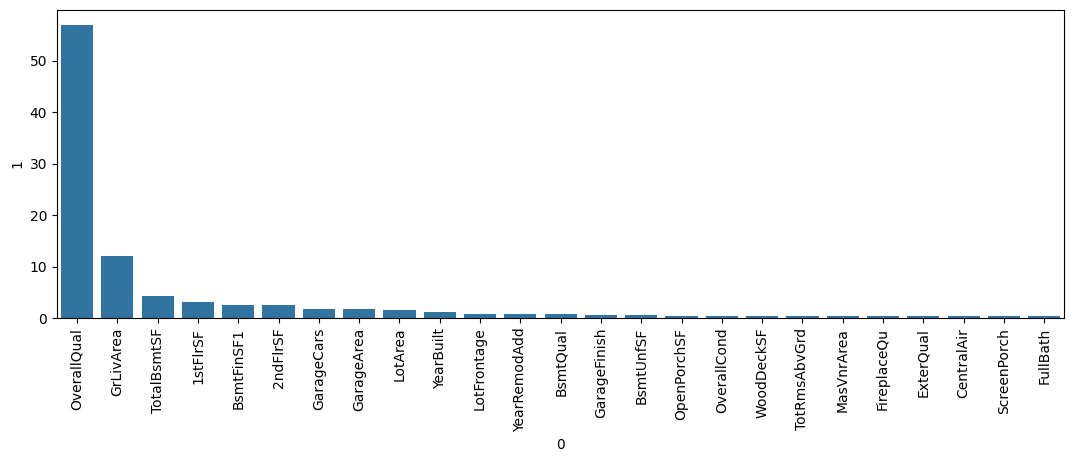

In [ ]:
plt.figure(figsize=(13, 4))
sns.barplot(x=fi[0].iloc[:25], y=fi[1].iloc[:25])
plt.xticks(rotation=90)
plt.show()

Our hypotesis is verified as no dummy variable is present in the 25 most important features, that gather combined 95 percent of the importance for price prediction. We will later perform the ANOVA test in order to verify if there are still categorical variables that are linked to price

--> let's create a new dataset only with these features

In [ ]:
fi[0].head(25).values.tolist()

['OverallQual',
 'GrLivArea',
 'TotalBsmtSF',
 '1stFlrSF',
 'BsmtFinSF1',
 '2ndFlrSF',
 'GarageCars',
 'GarageArea',
 'LotArea',
 'YearBuilt',
 'LotFrontage',
 'YearRemodAdd',
 'BsmtQual',
 'GarageFinish',
 'BsmtUnfSF',
 'OpenPorchSF',
 'OverallCond',
 'WoodDeckSF',
 'TotRmsAbvGrd',
 'MasVnrArea',
 'FireplaceQu',
 'ExterQual',
 'CentralAir',
 'ScreenPorch',
 'FullBath']

In [ ]:
scaled_topfi_X_train = scaled_X_train[fi[0].head(25).values.tolist()]
print(len(scaled_topfi_X_train))
scaled_topfi_X_test = scaled_X_test[fi[0].head(25).values.tolist()]
print(len(scaled_topfi_X_train))
scaled_topfi_train = scaled_X_train.copy()
print(len(scaled_topfi_X_train))
scaled_topfi_train['y']=y_train
print(len(scaled_topfi_X_train))

1314
1314
1314
1314


In [ ]:
len(scaled_X_train)

1314

In [ ]:
len(y_train)

1314

In [ ]:
print(len(scaled_topfi_X_train))

1314


## PCA

As we have around 50 numerical variables, we will be the create a new version of our feature set, but with less variables (dimentionality reduction). We will not select features from feature set, but rather create new features from our feature set. Each one of these new created features will be a linear combinaison of all our initial features, that gather as much information as they can (without being correlated). These are called components.

- The purpose  is here is **exploratory** : understand the meaning of the principal components to know the underlying information of our data

*We will then create a new version of our feature set (version where features will be the pca components). Note that we will accidently discover two outliers in out dataset that may bring down the performance of our future models. So they will be dropped*

The graph below represents the amount of information gathered from the original features according to the number of components that we keep

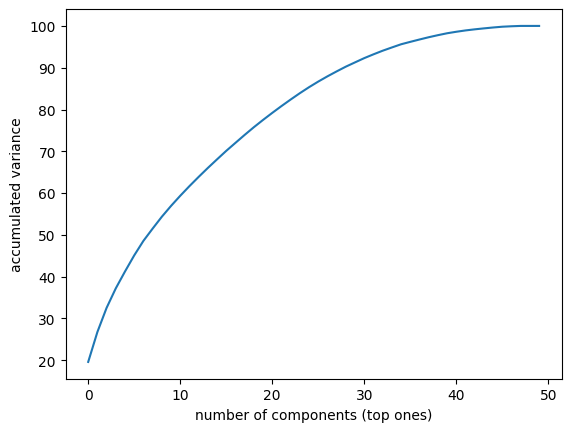

In [ ]:
pca = PCA(n_components=len(numer_X_train.columns))

numer_scaled_pc_X_train = pd.DataFrame(pca.fit_transform(numer_scaled_X_train))


components_variance = pca.explained_variance_ratio_*100
components_variance_accumulated = np.array([components_variance[i] + np.sum(components_variance[:i]) for i in range(len(components_variance))])
pd.Series(components_variance_accumulated).plot()
plt.xlabel('number of components (top ones)')
plt.ylabel('accumulated variance')
plt.show()

We want

--> as few components as possible

--> the highest possible accumulated variance (can be understood as the information gathered by the components)

We should note that the **component 1** gather as much variance as possible

**component 2** gather as much variance as possible witch has not been gathered by component 1

**component 3** gather as much variance as possible witch has not been gathered by component 1 and component 2

**etc**

- So the variance gathered decreases as we go through components from the top to the end one, but the accumulated variance increase (plot)

In [ ]:
len(components_variance_accumulated[components_variance_accumulated<80])

21

**If we want to keep 80 percent of the initial variance, we would need to keep 21 components**
This seems to be a good trade-off

In [ ]:
len(components_variance_accumulated[components_variance_accumulated<80])

21

(code executed in the data cleaning section)

In [ ]:
pca = PCA(n_components=21)

numer_scaled_pc_X_train = pd.DataFrame(pca.fit_transform(numer_scaled_X_train), index = numer_scaled_X_train.index)
numer_scaled_pc_X_test = pd.DataFrame(pca.fit_transform(numer_scaled_X_test), index = numer_scaled_X_test.index)
numer_scaled_pc_train = numer_scaled_pc_X_train.copy()
numer_scaled_pc_train['y']=y_train.sort_index()

let's check the components that are mostly correlated to *y* (in terms of absolute value correlations)

In [ ]:
abs(numer_scaled_pc_train.corr()['y']).sort_values(ascending=False)*100

,y
y,100.000000
0,86.573694
2,9.250682
1,8.468621
3,8.240268
4,7.458708
17,5.871146
5,5.091473
8,5.042899
11,4.963648


*We can notice a very high correlation between component 1 and the output (86 percent), but the correlations don't necessarly go down with the component rank. As we can see, some low rank components (like component 17) are more correlated to y than high rank components (like component 7). This is because the information gathered with the pca components is not necessarly the one correlated to y. Therefore, for predictions purposes, we will not use pca components*

**As we remarked a very high correlation between component 1 and y, let's plot these 2 variables into a graph**

Text(0, 0.5, 'y')

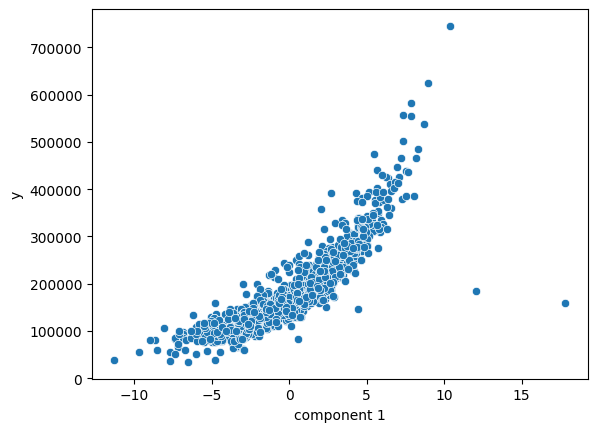

In [ ]:
sns.scatterplot(x=numer_scaled_pc_train[0], y=numer_scaled_pc_train['y'])
plt.xlabel('component 1')
plt.ylabel('y')

It looks like the relationship is polynomial, so let's see what we would get from a polynomial regression curve (degree 2 will be sufficient)

In [ ]:
poly_converter = PolynomialFeatures(degree = 2, include_bias=False)
numer_scaled_pc1_poly_X_train = pd.DataFrame(poly_converter.fit_transform(numer_scaled_pc_X_train[0].to_frame()), index = numer_scaled_pc_X_train.index)
numer_scaled_pc1_poly_X_test = pd.DataFrame(poly_converter.transform(numer_scaled_pc_X_test[0].to_frame()), index = numer_scaled_pc_X_test.index)

lr = LinearRegression()
lr.fit(numer_scaled_pc1_poly_X_train, y_train)

LinearRegression()

<ipython-input-79-7c203b282d21>:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x = numer_scaled_pc_train[0], y=preds, palette=['r'])


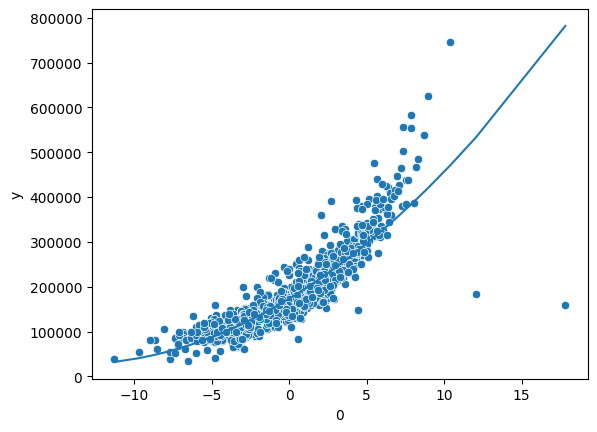

In [ ]:
preds = lr.predict(numer_scaled_pc1_poly_X_train)

sns.scatterplot(x=numer_scaled_pc_train[0], y=numer_scaled_pc_train['y'])
sns.lineplot(x = numer_scaled_pc_train[0], y=preds, palette=['r'])
plt.show()

In [ ]:
preds = lr.predict(numer_scaled_pc1_poly_X_test)
mape = mean_absolute_percentage_error(y_test, preds)
rmse = root_mean_squared_error(y_test, preds)
print('mean absolute percentage error (test set) : ', mape)
print('root mean squared error (test set) : ', rmse)

mean absolute percentage error (test set) :  0.1154688783564347
root mean squared error (test set) :  35242.50848591702


It seems that the two ouliers in bottom down are bringing down the regression curve, preventing it to go though the real trend of the data.

Let's drop them to see if the curve fits better then real trend

(see executed code in the data cleaning section)

In [ ]:
index_outliers = numer_scaled_pc_train[(numer_scaled_pc_train[0]>10) & (numer_scaled_pc_train['y']<250000)].index
index_outliers

numer_scaled_pc_train = numer_scaled_pc_train.drop(index_outliers)
numer_scaled_pc_X_train = numer_scaled_pc_X_train.drop(index_outliers)

numer_scaled_train = numer_scaled_train.drop(index_outliers)
numer_scaled_X_train = numer_scaled_X_train.drop(index_outliers)

numer_train = numer_train.drop(index_outliers)
numer_X_train = numer_X_train.drop(index_outliers)

scaled_train = scaled_train.drop(index_outliers)
scaled_X_train = scaled_X_train.drop(index_outliers)

train = train.drop(index_outliers)
X_train = X_train.drop(index_outliers)

y_train = y_train.drop(index_outliers)

In [ ]:
poly_converter = PolynomialFeatures(degree = 2, include_bias=False)
numer_scaled_pc1_poly_X_train = pd.DataFrame(poly_converter.fit_transform(numer_scaled_pc_X_train[0].to_frame()), index = numer_scaled_pc_X_train.index)
numer_scaled_pc1_poly_X_test = pd.DataFrame(poly_converter.transform(numer_scaled_pc_X_test[0].to_frame()), index = numer_scaled_pc_X_test.index)

lr = LinearRegression()
lr.fit(numer_scaled_pc1_poly_X_train, y_train)

LinearRegression()

<ipython-input-83-7c203b282d21>:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x = numer_scaled_pc_train[0], y=preds, palette=['r'])


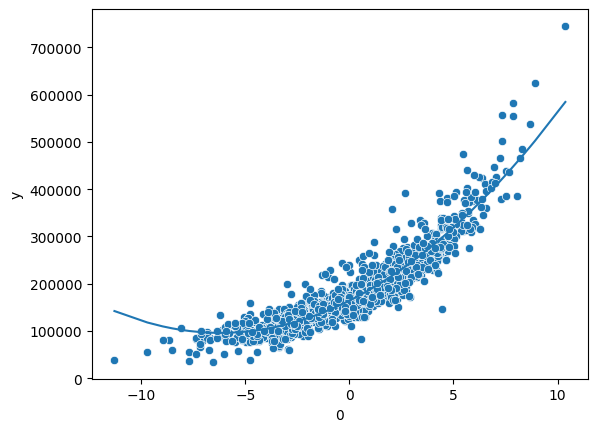

In [ ]:
preds = lr.predict(numer_scaled_pc1_poly_X_train)

sns.scatterplot(x=numer_scaled_pc_train[0], y=numer_scaled_pc_train['y'])
sns.lineplot(x = numer_scaled_pc_train[0], y=preds, palette=['r'])
plt.show()

The curve seems better right now

In [ ]:
preds = lr.predict(numer_scaled_pc1_poly_X_test)
mape = mean_absolute_percentage_error(y_test, preds)
rmse = root_mean_squared_error(y_test, preds)
print('mean absolute percentage error (test set) : ', mape)
print('root mean squared error (test set) : ', rmse)

mean absolute percentage error (test set) :  0.11750698965179629
root mean squared error (test set) :  27589.819380393677


We also got better error metrics values on test set (especially root mean squared error)

## CCA (canonical correlation analysis) [explications in further versions of the project]

In [ ]:
numer_scaled_X_train.head()

,LotFrontage,LotArea,Street,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,MoSold,YrSold,LotIrregularity
907,0.828499,0.084557,-0.061804,-0.226985,0.650071,1.282993,-1.149679,0.105391,-0.583936,1.054453,-0.245608,0.585262,0.111308,-0.589150,-0.489611,-0.279269,0.510827,-0.091069,-0.145790,0.267914,-0.374017,1.573191,-0.115327,1.035525,-0.814662,-0.241125,-1.036178,1.225098,0.150991,-0.215886,0.744873,-0.337025,0.595745,1.194526,1.307561,-1.037159,-1.391842,-1.121741,0.265876,-0.748606,-0.709671,-0.357887,-0.122175,5.450039,-0.072426,-0.069836,-0.089448,-0.128250,-1.364068,0.998271
782,0.281816,0.543774,-0.061804,-0.226985,0.650071,-0.520058,0.984929,0.830435,-0.583936,1.054453,-0.245608,0.585262,0.111308,-0.589150,-0.979513,-0.279269,1.906397,0.818618,0.895339,0.267914,0.693131,-0.804206,-0.115327,-0.173416,-0.814662,-0.241125,0.776788,-0.762283,0.150991,-0.215886,0.744873,-0.337025,-0.957447,-1.016189,0.328566,0.310840,0.631209,0.259672,0.265876,-0.748606,-0.220601,-0.357887,-0.122175,-0.271111,-0.072426,-0.069836,-0.089448,-0.128250,0.884847,2.701813
952,0.080406,-0.328114,-0.061804,-0.226985,-0.806355,2.184519,0.032565,0.878772,-0.583936,-0.692774,2.536542,0.585262,0.111308,1.299005,0.470421,-0.279269,-1.035799,-0.663070,-0.145790,0.267914,-1.029922,-0.804206,-0.115327,-1.449842,-0.814662,3.927804,-1.036178,-0.762283,-1.081322,-0.215886,-0.770240,-0.958135,-0.957447,-1.016189,1.307561,-1.037159,-0.363657,0.259672,0.265876,0.766344,-0.709671,-0.357887,-0.122175,-0.271111,-0.072426,-0.069836,-0.089448,-0.872269,0.884847,-0.705272
620,-0.351186,-0.227537,-0.061804,-0.226985,-2.262781,-2.323109,-1.872162,-1.683052,-0.583936,-0.692774,-0.245608,-0.564266,0.111308,-0.589150,-0.889441,-0.279269,0.576209,-0.442540,-1.186918,-3.732535,-0.780053,-0.804206,-0.115327,-1.264741,1.103735,-0.241125,-1.036178,-0.762283,-1.081322,-0.215886,-0.770240,-0.958135,-0.957447,-1.016189,-2.608416,-2.385157,-2.248664,-3.884568,-3.893185,-0.748606,-0.709671,1.259140,-0.122175,-0.271111,-0.072426,-0.069836,-0.089448,0.987779,0.135209,-0.705272
669,0.655862,0.094154,-0.061804,-0.226985,-1.534568,-0.520058,-1.609441,-1.683052,-0.583936,-0.692774,-0.245608,-1.713793,0.111308,-0.589150,-0.979513,-0.279269,0.298899,-0.819279,0.895339,0.267914,0.042431,-0.804206,-0.115327,-0.655450,-0.814662,-0.241125,-1.036178,-0.762283,-1.081322,-0.215886,-2.285352,-0.958135,0.595745,1.194526,-0.650428,-1.037159,-1.049114,0.259672,-1.120478,-0.748606,-0.709671,0.725521,-0.122175,-0.271111,-0.072426,-0.069836,-0.089448,0.243760,-1.364068,-0.705272


In [ ]:
from sklearn.cross_decomposition import CCA

cca = CCA(n_components=1)
cca.fit(numer_scaled_X_train, y_train)
scaled_numer_cca_X_train = pd.DataFrame(cca.transform(numer_scaled_X_train), index = numer_scaled_X_train.index)
scaled_numer_cca_X_test = pd.DataFrame(cca.transform(numer_scaled_X_test), index = numer_scaled_X_test.index)

scaled_numer_cca_train = scaled_numer_cca_X_train.copy()
scaled_numer_cca_train['y']=y_train

correlation between the cca component and the price is 94 percent (pca component was 86 percent)

In [ ]:
cca.coef_[0].tolist()

[7563.626313923415,
 10089.534772009503,
 -3910.0838861404495,
 1102.6818056337058,
 28961.994182184502,
 15321.827107818372,
 17033.022349177747,
 -2440.9998876131276,
 7324.519719376287,
 12973.074325786072,
 -1961.1742868413194,
 6677.531657400873,
 -13342.71713742673,
 9299.446867769293,
 20944.35563966995,
 1415.9342532533576,
 1878.5353737872636,
 24864.019584395224,
 2264.172118816374,
 -789.6372008303978,
 15479.303977550644,
 21844.46618480552,
 -2090.2425524164714,
 30911.08688779097,
 -780.3839491508683,
 -3968.155033705796,
 -892.2124337269166,
 1235.9713585974591,
 -14152.12315472156,
 -12201.885684406458,
 11180.928571453034,
 15240.34984310544,
 2108.925464893803,
 1720.451239629529,
 -162.8406570393045,
 2687.555651288776,
 13510.056418715429,
 3236.9447995038036,
 -12104.661966261257,
 3550.957649856864,
 1303.4229807953443,
 -1325.4771378061096,
 899.8781630128493,
 3933.932083659806,
 -8448.010051433885,
 15705.873602681953,
 -189.41687171792407,
 117.33081927189217,

In [ ]:
fi[0].head()

,0
4,OverallQual
23,GrLivArea
17,TotalBsmtSF
20,1stFlrSF
14,BsmtFinSF1


In [ ]:
pd.DataFrame([cca.coef_[0].tolist()], columns = numer_scaled_X_train.columns.tolist()).T.sort_values(by=0)

,0
BedroomAbvGr,-14152.123155
BsmtCond,-13342.717137
KitchenAbvGr,-12201.885684
GarageCond,-12104.661966
PoolArea,-8448.010051
BsmtHalfBath,-3968.155034
Street,-3910.083886
YearRemodAdd,-2440.999888
LowQualFinSF,-2090.242552
ExterCond,-1961.174287


In [ ]:
scaled_numer_cca_train.corr()['y'].loc[0]

0.9400198235416347

Text(0, 0.5, 'y')

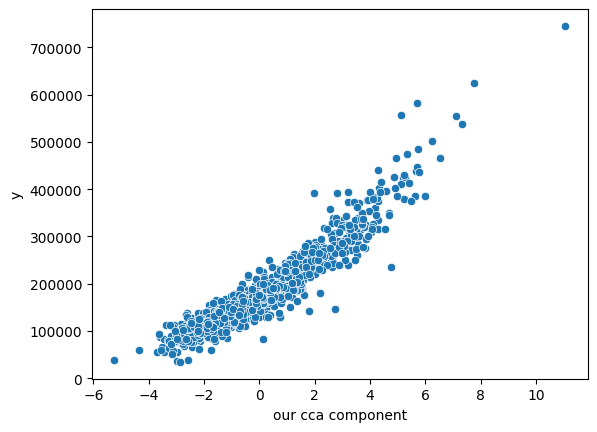

In [ ]:
sns.scatterplot(x = scaled_numer_cca_X_train[0], y = y_train)
plt.xlabel('our cca component')
plt.ylabel('y')

In [ ]:
lr = LinearRegression()
lr.fit(scaled_numer_cca_X_train, y_train)
preds = lr.predict(scaled_numer_cca_X_test)
mape = mean_absolute_percentage_error(y_test, preds)
rmse = root_mean_squared_error(y_test, preds)

In [ ]:
mape

0.11903715937965939

In [ ]:
rmse

33971.0625693235

# **II. Prediction Models**

Accuracy generally improves with
- Number of predictive features
- Hyperparameter optimisation of a model

## Step 1 : train/testing different models on different dataset versions to choose the best pipeline for the final predictions in kaggle

### Model 1 : Random Forest Regressor [mape = 9.14%, rmse = 29722]
We will create and evaluate 3 versions of Random Forest Regressor

#### No Hyperparameter tuning (default ones)

In [257]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
preds1_1 = model.predict(X_test)

mean absolute percentage error

In [258]:
mean_absolute_percentage_error(y_test, preds1_1)*100

9.2639902734267

mean absolute error

In [259]:
mean_absolute_error(y_test, preds1_1)

16519.397397260273

root mean squared error

In [260]:
root_mean_squared_error(y_test, preds1_1)

30749.38109991257

#### Hyperparameter tuning through GridSearchCV

In [ ]:
model = RandomForestRegressor()

param_grid = {
        "n_estimators"      : [50, 100, 150, 200],
        "max_features"      : ["sqrt", "log2", 1.0],
        "min_samples_split" : [2,4,8],
        "bootstrap": [True, False]
        }

cvmodel = GridSearchCV(model, param_grid, n_jobs=-1, cv=5, verbose = 5, scoring='neg_mean_squared_error')
cvmodel.fit(scaled_X_train, y_train)
preds1_2 = cvmodel.predict(scaled_X_test)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


mean absolute percentage error

In [ ]:
mean_absolute_percentage_error(y_test, preds1_2)*100

9.485998635491962

mean absolute error

In [ ]:
mean_absolute_error(y_test, preds1_2)

16911.621461187213

root mean squared error

In [ ]:
root_mean_squared_error(y_test, preds1_2)

33740.09960376338

In [ ]:
cvmodel.best_params_

{'bootstrap': False,
 'max_features': 'sqrt',
 'min_samples_split': 2,
 'n_estimators': 150}

#### Hyperparameter tuning throught Bayestian optimisation

In [ ]:
def objective(trial):
    # Suggest values for hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 4)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    # Create the model with suggested hyperparameters
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42
    )

    # Evaluate the model using cross-validation
    score = cross_val_score(model, scaled_X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean()
    print(score)

    # Return the negative score (Optuna minimizes by default)
    return score

study = optuna.create_study(direction='maximize')  # Minimize the objective function
study.optimize(objective, n_trials=150)  # Perform 150 trials

# Print the best hyperparameters and score
print("Best hyperparameters:", study.best_params)
print("Best score:", study.best_value)

[I 2025-02-28 08:48:13,282] A new study created in memory with name: no-name-02c102aa-bc5a-42d4-83aa-2c231a7d0ded
[I 2025-02-28 08:48:22,656] Trial 0 finished with value: -31872.18758271038 and parameters: {'n_estimators': 166, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 0 with value: -31872.18758271038.


-31872.18758271038


[I 2025-02-28 08:48:24,082] Trial 1 finished with value: -35755.72915437948 and parameters: {'n_estimators': 94, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: -31872.18758271038.


-35755.72915437948


[I 2025-02-28 08:48:27,377] Trial 2 finished with value: -29561.949626234797 and parameters: {'n_estimators': 163, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 2 with value: -29561.949626234797.


...

-40258.275657794


[I 2025-02-28 08:49:28,486] Trial 10 finished with value: -28894.63546014973 and parameters: {'n_estimators': 236, 'max_depth': 30, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 10 with value: -28894.63546014973.


-28894.63546014973


[I 2025-02-28 08:49:55,713] Trial 11 finished with value: -28896.248724028927 and parameters: {'n_estimators': 240, 'max_depth': 30, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 10 with value: -28894.63546014973.


-28896.248724028927


In [ ]:
best_params = study.best_params

final_model = RandomForestRegressor(**best_params, random_state=42)
final_model.fit(scaled_X_train, y_train)

preds1_3 = final_model.predict(scaled_X_test)

In [ ]:
best_params

mean absolute percentage error

In [ ]:
mean_absolute_percentage_error(y_test, preds1_3)*100

mean absolute error

In [ ]:
mean_absolute_error(y_test, preds1_3)

root mean squared error

In [ ]:
root_mean_squared_error(y_test, preds1_3)

#### Conclusion

We got about the same mean percentage error (about 9.5 percent : 16747 euros) regardless of the the presence of hyperparameter optimisation of its method

In [ ]:
root_mean_squared_error(y_test, preds1_1)

In [ ]:
np.std(y_test)

a "best guess" model would always guess the mean price as the price of a house.

- the root_mean_square_error of our "best guess" model would be the standard deviation (sum of square differences between price and mean). In this case, it is equal to 95 585 euros

- the root_mean_square_error of our Random Forest model is 30 830 euros.

Therefore, our model "divides by 3" the "best guess" error (kind of)

#### Get feature importances (the code is executed in the data cleaning section)

Creation of a new version of the feature set that involves only the most relevant features according to the random forest regressor model (dimentionnality reduction)

In [ ]:
# pass

### Model 2 : Ordinary Least Square Regression (Classical) [mape = 11.91%, rmse = 33973]

Because we noticed that Linear Regression can hallucinate with predictions when the data is categorical, we will use only numerical features

In [ ]:
get_best_regression_degree(numer_scaled_X_train, y_train, LinearRegression(), range=range(1, 4))


 degree in process :  1
number of features :  50
mean_absolute_percentage_error (mean CV):  0.12168906461058829
mean_absolute_percentage_error (on the training set) :  0.11443557719033037

 degree in process :  2
number of features :  1325
mean_absolute_percentage_error (mean CV):  232829107.9468553
mean_absolute_percentage_error (on the training set) :  0.03309592178644089

 degree in process :  3
number of features :  23425
mean_absolute_percentage_error (mean CV):  0.16282887322719372
mean_absolute_percentage_error (on the training set) :  9.953116633205748e-15


(0, -0.16282887322719372)

In [ ]:
lr = LinearRegression()

lr.fit(numer_scaled_X_train, y_train)
preds2 = lr.predict(numer_scaled_X_test)

mape = mean_absolute_percentage_error(y_test, preds2)
rmse = root_mean_squared_error(y_test, preds2)

mean absolute percentage error

In [ ]:
mape

0.11915062531206491

mean absolute error

In [ ]:
mean_absolute_error(y_test, preds2)

20491.733571849883

root mean squared error

In [ ]:
rmse

33973.85496614337

### Model 3 : Ordinary Least Square Regression (ElasticNet) [mape = 9.9%, rmse = 33865]

Elastic net handle better categorical features, so we will inclue them in the dataset

In [ ]:
elastic_model = ElasticNetCV(l1_ratio=[.1, .5, .7,.9, .95, .99, 1],tol=0.01)

elastic_model.fit(scaled_X_train, y_train)
preds3 = elastic_model.predict(scaled_X_test)

mean percentage absolute error

In [ ]:
mean_absolute_error(y_test, preds3)

0.09899025062480972

mean absolute error

In [ ]:
mean_absolute_error(y_test, preds3)

root mean squared error

In [ ]:
root_mean_squared_error(y_test, preds3)

33864.83243874577

### Model 4 : Support Vector Machines Regressor [mape = 10.83%, rmse = 33420]

#### No hyperparameter optimisation (default hyperparameters)

In [ ]:
svr = SVR()
svr.fit(numer_scaled_X_train, y_train)
preds4_1 = svr.predict(numer_scaled_X_test)
mape = mean_absolute_percentage_error(y_test, preds4_1)
rmse = root_mean_squared_error(y_test, preds4_1)

mean absolute percentage error

In [ ]:
print(mape)

0.35707795592603614


mean absolute error

In [ ]:
print(mean_absolute_error(y_test, preds4_1))

62935.61259521903


root mean squared error

In [ ]:
print(rmse)

97291.368633669


#### Hyperparameter optimisation through GridSearchCV

- scaled_X_train
- numer_scaled_X_train
- scaled_topfi_X_train

In [ ]:
svr = SVR()

param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['linear', 'poly', 'rbf', 'sigmoid']}

svrcv = GridSearchCV(svr, param_grid, cv=5, scoring='neg_root_mean_squared_error', verbose=5)
svrcv.fit(scaled_topfi_X_train, y_train)
preds4_2 = svrcv.predict(scaled_topfi_X_test)
mape = mean_absolute_percentage_error(y_test, preds4_2)
rmse = root_mean_squared_error(y_test, preds4_2)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5] END C=0.1, gamma=1, kernel=linear;, score=-74547.456 total time=   0.4s
[CV 2/5] END C=0.1, gamma=1, kernel=linear;, score=-87201.561 total time=   0.4s
[CV 3/5] END C=0.1, gamma=1, kernel=linear;, score=-84677.982 total time=   0.4s
[CV 4/5] END C=0.1, gamma=1, kernel=linear;, score=-72670.825 total time=   0.4s
[CV 5/5] END C=0.1, gamma=1, kernel=linear;, score=-73579.608 total time=   0.2s
[CV 1/5] END ..C=0.1, gamma=1, kernel=poly;, score=-33413.333 total time=   0.3s
[CV 2/5] END ..C=0.1, gamma=1, kernel=poly;, score=-39866.189 total time=   0.2s
[CV 3/5] END ..C=0.1, gamma=1, kernel=poly;, score=-39086.081 total time=   0.2s
[CV 4/5] END ..C=0.1, gamma=1, kernel=poly;, score=-40665.938 total time=   0.2s
[CV 5/5] END ..C=0.1, gamma=1, kernel=poly;, score=-34300.733 total time=   0.3s
[CV 1/5] END ...C=0.1, gamma=1, kernel=rbf;, score=-75084.157 total time=   0.5s
[CV 2/5] END ...C=0.1, gamma=1, kernel=rbf;, s

mean absolute percentage error

In [ ]:
mape

0.10949567744884964

mean absolute error

In [ ]:
mean_absolute_error(y_test, preds4_2)

20662.626518697554

root mean squared error

In [ ]:
rmse

39688.87299462439

### Model 5 : KNN Regressor [mape = 9.90%, rmse = 33864]

We do hyperparameter tuning by displaying the graph of the error of the model for each k value, so that we choose k that show the lowest error (k representing the number of nearest neibors considered for predictions)

Unlike other models, knn is very sensitive to the relevance of the features for y predicitions. Therefore, it is interesting to see with what version of the dataset will it perform the best. We will not display all the trials, but here is a ranking of the feature set version in terms of error metrics, from the worse to the best :
- X_train
- scaled_X_train
- numer_scaled_X_train
- scaled_topfi_X_train
- scaled_topfi_scaletopfi_X_test

In [ ]:
scaled_topfi_scaletopfi_X_train = scaled_topfi_X_train.copy()
scaled_topfi_scaletopfi_X_train *= np.sqrt(np.array(fi[1][:25]).tolist())

scaled_topfi_scaletopfi_X_test = scaled_topfi_X_test.copy()
scaled_topfi_scaletopfi_X_test *= np.sqrt(np.array(fi[1][:25]).tolist())

In [ ]:
test_error_rates_uni = []


for k in range(1,30):

    knn = KNeighborsRegressor(n_neighbors=k)

    score = cross_val_score(knn, scaled_topfi_scaletopfi_X_train, y_train, cv=5, scoring='neg_mean_absolute_percentage_error').mean()
    error = -score

    test_error_rates_uni.append(error)

In [ ]:
test_error_rates_dist = []


for k in range(1,30):

    knn = KNeighborsRegressor(n_neighbors=k, weights='distance')

    score = cross_val_score(knn, scaled_topfi_scaletopfi_X_train, y_train, cv=5, scoring='neg_mean_absolute_percentage_error').mean()
    error = -score

    test_error_rates_dist.append(error)

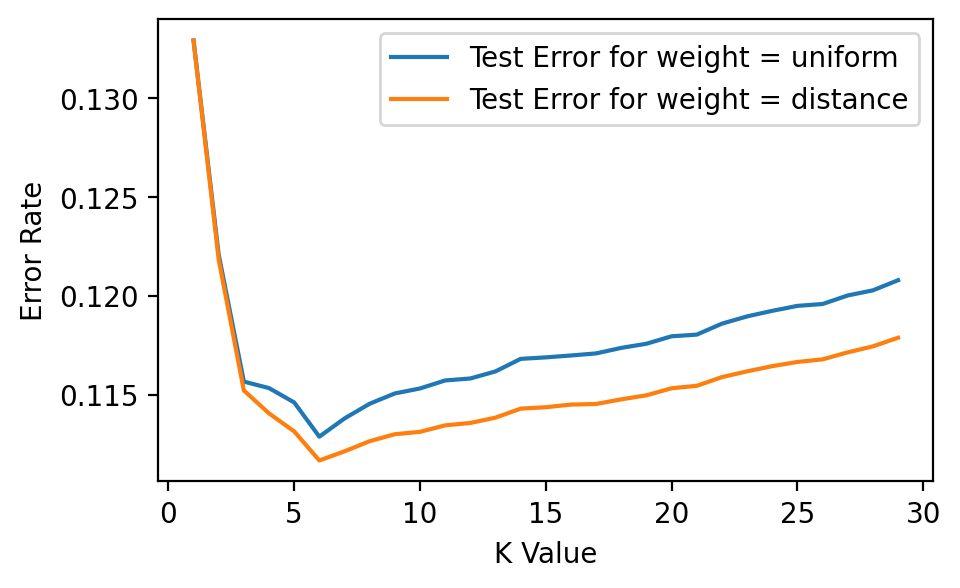

In [ ]:
plt.figure(figsize=(5,3),dpi=200)
plt.plot(range(1,30),test_error_rates_uni,label='Test Error for weight = uniform')

plt.plot(range(1,30),test_error_rates_dist,label='Test Error for weight = distance')

plt.legend()
plt.ylabel('Error Rate')
plt.xlabel("K Value")
plt.show()

We can see in the graph above that the best values for k are between 5 and 11. We will choose k=6

In [ ]:
model = KNeighborsRegressor(n_neighbors=10, weights = 'distance')

In [ ]:
model.fit(scaled_topfi_scaletopfi_X_train, y_train)
preds5 = model.predict(scaled_topfi_scaletopfi_X_test)
mape = mean_absolute_percentage_error(y_test, preds5)
rmse = root_mean_squared_error(y_test, preds5)

root mean squared error

In [ ]:
rmse

34249.04579602127

mean absolute percentage error

In [ ]:
mape

0.10265763992343671

## Choosing the best pipeline for final kaggle prediction + expected error visualisation

29740.186171997106

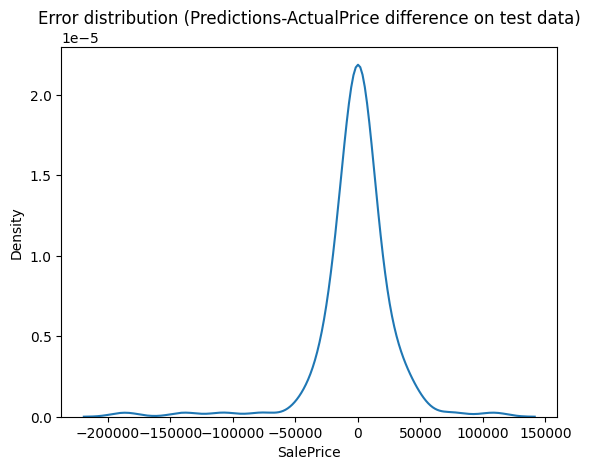

In [ ]:
errors = preds1_1 - y_test
sns.kdeplot(errors)
plt.title('Error distribution (Predictions-ActualPrice difference on test data)')
errors.std()

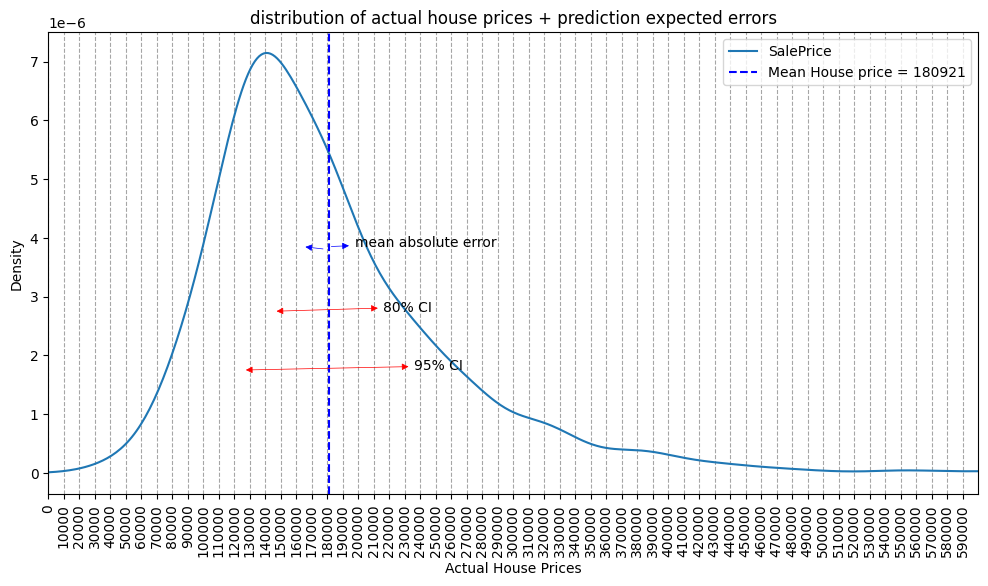

In [ ]:
plt.figure(figsize=(12, 6))

y.plot(kind='kde')

plt.gca().ticklabel_format(style='plain', axis='x')
plt.xticks(np.arange(0, 600000, 10000), rotation=90)
plt.xlim(0, 600000)
plt.grid(axis='x', linestyle='--', color='gray', alpha=0.7)
mean_value = y.mean()
plt.axvline(mean_value, color='blue', linestyle='--', linewidth=1.5, label=f'Mean House price = {mean_value:.0f}')

mae = 16754
confidence_80 = 27589*1.282
confidence_95 = 27589*2

y_middle = plt.gca().get_ylim()[1] / 2
y_lower = y_middle - 10**-6
y_lower2 = y_lower - 10**-6

plt.annotate('mean absolute error', xy=(mean_value, y_middle+10**-7),
             xytext=(mean_value + mae, y_middle+10**-7),
             arrowprops=dict(arrowstyle='<|-', color='blue', lw=0.5))

plt.annotate('                   ', xy=(mean_value - mae, y_middle+10**-7),
             xytext=(mean_value, y_middle-10**-7),
             arrowprops=dict(arrowstyle='-|>', color='blue', lw=0.5))

plt.annotate('80% CI',
             xy=(mean_value - confidence_80, y_lower),
             xytext=(mean_value + confidence_80, y_lower),
             arrowprops=dict(arrowstyle='<|-|>', color='red', lw=0.5))

plt.annotate('95% CI',
             xy=(mean_value - confidence_95, y_lower2),
             xytext=(mean_value + confidence_95, y_lower2),
             arrowprops=dict(arrowstyle='<|-|>', color='red', lw=0.5))

plt.xlabel("Actual House Prices")
plt.title("distribution of actual house prices + prediction expected errors")
plt.legend()

plt.show()

In [ ]:
pd.read_csv('test.csv').head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## Final Predictions for kaggle

training model on all training data (no portion left for test)

In [273]:
model = RandomForestRegressor()
model.fit(X, y)

RandomForestRegressor()

Using the trained model for final test kaggle predictions

In [274]:
final_kaggle_preds = model.predict(X_final_test)

In [275]:
final_kaggle_preds = pd.DataFrame({'Id' : id_serie, 'SalePrice' : final_kaggle_preds})

In [276]:
final_kaggle_preds

,Id,SalePrice
0,1461,128079.00
1,1462,154427.50
2,1463,178948.40
3,1464,182525.50
4,1465,194646.30
5,1466,185926.80
6,1467,165513.11
7,1468,177099.29
8,1469,182732.81
9,1470,118246.00


In [277]:
final_kaggle_preds.to_csv('final_kaggle_preds.csv', index=False)

# **I. Exploratory Data Analysis**

## Feature Selection (Num : Pearson Correlation, cat : dismissed)

In [ ]:
df.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageCars', 'GarageArea',
       'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       '

In [ ]:
len(df.columns)

84

*In this context, the importance of a feature of a house is based on its relation to the price*

*This is true in a buisness context of selling, but also intuitively, if a feature is important, this means that the buyer would be willing to pay more for it (it has an impact on the value of the house)*

*Therefore, we will have that as a choosing criteria not only for the regression model of price prediction but also clustering*

In [ ]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']

numer_df = df.select_dtypes(include=numerics)

In [ ]:
len(numer_df.columns)

56

**1) take the numerical features most correlated with the price (at least 40% correlation)**

In [ ]:
# sns.boxplot(data=numer_df, x='OverallQual', y='SalePrice')

In [ ]:
numer_df.columns

Index(['LotFrontage', 'LotArea', 'Street', 'LandSlope', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'HeatingQC', 'CentralAir',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Fireplaces', 'FireplaceQu',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'PoolQC', 'MiscVal', 'MoSold', 'YrSold',
       'SalePrice', 'LotIrregularity', 'BsmtExposureExist', 'BsmtExist',
       'GarageExist', 'PoolExist', 'FenceExist'],
      dtype='object')

**Our feature set will first be all the numerical features that are correlated to the price more than 40 percent**

In [ ]:
corrs = numer_df.corr()['SalePrice'].sort_values(ascending=False)
feature_set = corrs[corrs>0.4].index.tolist()
feature_set
# 2ndFlrSF

['SalePrice',
 'OverallQual',
 'GrLivArea',
 'ExterQual',
 'KitchenQual',
 'GarageCars',
 'GarageArea',
 'TotalBsmtSF',
 '1stFlrSF',
 'BsmtQual',
 'FullBath',
 'GarageFinish',
 'TotRmsAbvGrd',
 'YearBuilt',
 'FireplaceQu',
 'YearRemodAdd',
 'MasVnrArea',
 'Fireplaces',
 'HeatingQC']

In [ ]:
len(feature_set) - 1
# we have 19 features

18

- Because 1stFlrSF + 2ndFlrSF = GrLivArea,
we will replace GrLivArea by 2ndFlrSF in our set of features

In [ ]:
df[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea']].head()
# df['1stFlrSF']-df['TotalBsmtSF']

,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea
0,856,856,854,1710
1,1262,1262,0,1262
2,920,920,866,1786
3,756,961,756,1717
4,1145,1145,1053,2198


In [ ]:
feature_set.remove('GrLivArea')
feature_set.append('2ndFlrSF')

In [ ]:
len(feature_set) - 1
# we still have 19 features

18

- We will not take into account the variable 'OverallQual' that refer to an overall quality assessment made by a professional, because it is not useful in the context of searching what are the impacts of the house characteristics on the price

In [ ]:
feature_set.remove('OverallQual')

In [ ]:
len(feature_set) - 1
# We are now left with 18 features

17

<Axes: >

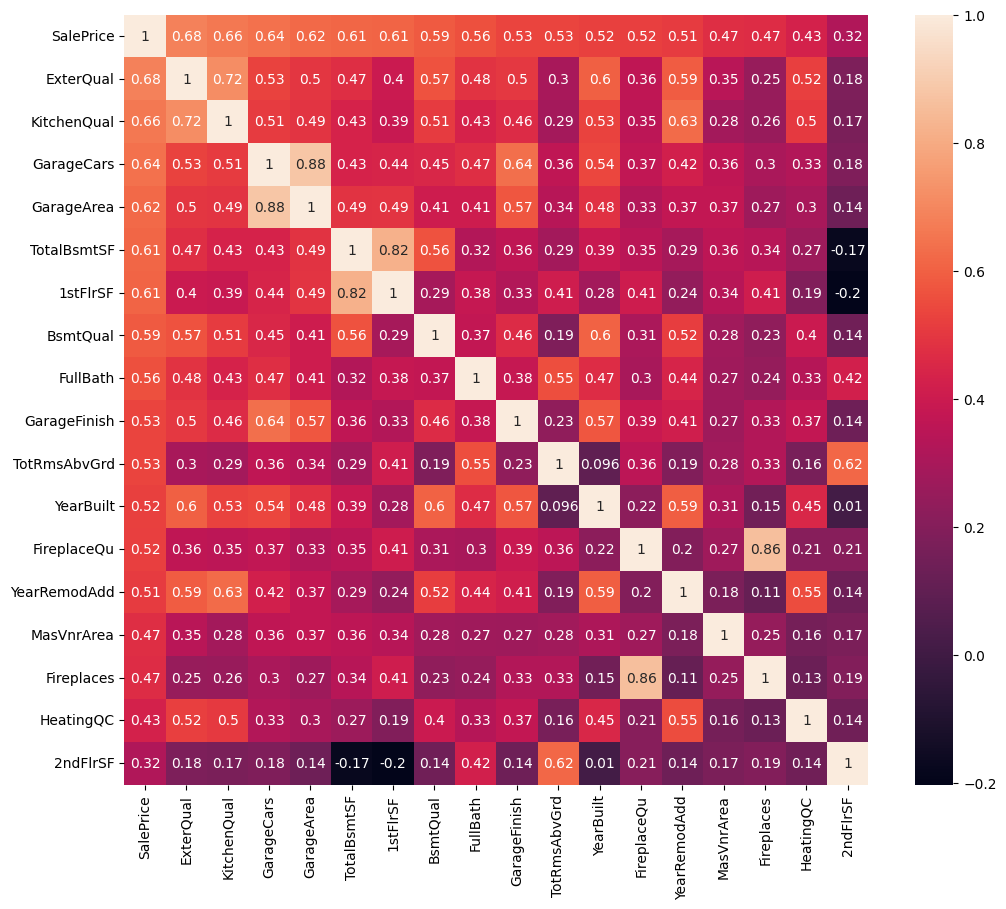

In [ ]:
# GrLivArea, GarageCars, TotalBsmtSF, GarageArea, 1stFlrSF, 2ndFlrSF, FullBath, TotRmsAbvGrd, YearBuilt, GarageFinish,   YearRemodAdd, GarageYrBlt, MasVnrArea, Fireplaces, PoolQC, HeatingQC

plt.figure(figsize=(12, 10))
sns.heatmap(df[feature_set].corr(), annot=True)

*When two features are very correlated, we only keep the one witch has the most direct impact on the price*

GarageArea(0.61), GarageCars(0.64) --> **GarageCars**

YearBuilt(0.52), GarageYrBlt(0.49) --> **YearBuilt**

In [ ]:
feature_set.remove('GarageArea')
feature_set.remove('GarageYrBlt')

ValueError: list.remove(x): x not in list

In [ ]:
len(feature_set) - 1
# now we are left with 16 features

Now, we are left with 16 features, so we still need to drop 6 features to get only 10

In [ ]:
df[feature_set].isnull().sum()

We will drop PoolQC as it has too many NaN values

In [ ]:
feature_set.remove('PoolQC')

In [ ]:
len(feature_set) - 1

- We will choose the features that refer to

1) the quantity (surface area or couting something) : *GarageCars, FullBath, TotalBsmtSF, 1stFlrSF, 2ndFlrSF, MasVnrArea*

2) the quality (rating) : *ExterQual, KitchenQual, BsmtQual, HeatingQC*

This way we can group the features to get better insights

*We have prioritized the features that are better correlated with the price*

In [ ]:
df[feature_set].corr()['SalePrice']

In [ ]:
feature_set = ['ExterQual', 'KitchenQual', 'BsmtQual', 'HeatingQC', 'GarageCars', 'FullBath', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'MasVnrArea']
feature_set

In [ ]:
df[feature_set].isnull().sum()

In [ ]:
len(feature_set)

## 1. Clustering Method 1:

- Identify the characteristics of each cluster by analyzing the cluster centers and the mean values of the variables for each cluster.
- Discuss the potential business implications of the identified clusters.

### **kmeans clustering**

In [ ]:
X = df[feature_set].drop('SalePrice', axis=1).dropna()

In [ ]:
len(X)

In [ ]:
X.head()

*SSD (sum of squared distances) is the most important "error" metric when it comes to clustering. It is the sum of the squared distances of all points to the center of their corresponding cluster.*

*We will see how SSD changes when we increase the number of clusters in our model. From that we will choose what is the ideal number of clusters that fits the best our dataset of houses.*

We can see in the graph the k=3 is the "elbow" point, meaning the number of clusters that seperate the best our houses into homogenious groups

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

In [ ]:
ssd = []

for k in range(1,20):

    model = KMeans(n_clusters=k);


    model.fit(scaled_X);

    #Sum of squared distances of samples to their closest cluster center.
    ssd.append(model.inertia_)

In [ ]:
plt.plot(range(1,20),ssd,'o--')
plt.xlabel("K Value")
plt.ylabel(" Sum of Squared Distances")
plt.ylim(0, 15000)

In [ ]:
model = KMeans(n_clusters=3, random_state=99);

model.fit(scaled_X);

preds = model.predict(scaled_X)

model.inertia_

### **cluster analysis**

"Cluster 0" (low quality houses):
- lowest values in all features

"Cluster 1" VS "Cluster 2":

- Exept the 1stFlrSF and 2ndFlrSF, the feature value averages look a little bit higher in cluster 2 than in cluster 1.
- It looks like in total, the two clusters have on average the same number of Square Feet (1800), if we add up the ones of the first and second Floor. However the surface is distributed very differently among the floors between these two clusters : The cluster 2 seems to have its surface focused only on the first floor, while the cluster 1 seems to have its surface equally distributed between the first and second floor. However, cluster 2 should still have an advantage on this aspect because the value of a 1st floor SF (74) is higher than the value of a 2nd floor SF (55) *(see regression analysis 1)*

In [ ]:
X['Cluster']=preds
clusters =  X.groupby('Cluster').mean()
clusters.T

In [ ]:
x = pd.DataFrame(scaler.fit_transform(clusters), columns = clusters.columns).T
sns.heatmap(x)

Let's look at the distribution of 2ndFlrSF in cluster 2

- Our intuition was right, the mean value of 2ndFlrSF was very low in cluster 2 because most of its houses simply does not have a second floor (SF=0)

In [ ]:
sns.displot(X[X['Cluster']==2]['2ndFlrSF'])
plt.title('distribution of 2ndFlrSF in cluster 2')

With what we have, and knowing that our features are positively correlated with the price, we can conjecture that the most expensive houses would be in cluster 2. Cluster 1 should have average prices and cluster 0 should have very cheap houses. Let's approve or disapprove our hypotesis

In [ ]:
X = df[feature_set].dropna()
X['Cluster']=preds

In [ ]:
X.groupby('Cluster').mean()['SalePrice']

Our intuition has been confirmed (obviously as it is performed by Adam). This means that our clustering analysis was right, but also that the 10 features that we have been selecting from the 81 initial ones have, when combined, a significant impact on the price (if we had chosen a non-relevant set of features, the price would have been very similar across the clusters). Let's take some time to appreciate the hardwork that led us to this result.

## 2. Clustering Method 2

- Identify the characteristics of each cluster by analyzing the cluster centers and the mean values of the variables for each cluster.
- Compare the results with the first clustering method and discuss the differences and similarities.
- Provide insights into all the final clusters made in this section

### **hierarchical clustring**

In [ ]:
X = df[feature_set].drop('SalePrice', axis=1).dropna()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

For the hierarchical clustering, let's set the number of clusters equal to 3, similar to the kmeans clustering that we have done. This way we can make better comparisons between the two results

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy

model = AgglomerativeClustering(n_clusters=3)

cluster_labels = model.fit_predict(scaled_X)

linkage_matrix = hierarchy.linkage(model.children_)

In [ ]:
plt.figure(figsize=(10,5))
# Warning! This plot will take awhile!!
dn = hierarchy.dendrogram(linkage_matrix, truncate_mode='lastp',p=15)

### **clustering results comparison**

We got nearly the same results for two different clustering methods, witch could mean that the clusters that we got represent well the data that we have (at least for the features that we have chosen)

In [ ]:
X['Cluster']=cluster_labels
clusters = X.groupby('Cluster').mean().T
clusters = clusters.rename(columns={1: 0, 0: 1})
clusters

In [ ]:
f, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
scaled_clusters = scaler.fit_transform(clusters.T)

y = pd.DataFrame({0 : scaled_clusters[1], 1: scaled_clusters[0], 2: scaled_clusters[2]})

sns.heatmap(x, ax = ax[0])
ax[0].set_title("heatmap kmeans clustering")
sns.heatmap(y, ax = ax[1])
ax[1].set_title("heatmap hierarchical clustering")

plt.tight_layout()

### **buisness conclusion (on the two clusterings)**

In buisness words, the clustering that we have been doing regroups the houses into 3 categories (these categories are where the offer and demand meet). As ideally, we want a house with features with low offer and high demand, there can be two types of strategies :

**1- prioritize high demand :** make the house correspond to one of these cluster in order to make sure that there will be demand (but at what price as they are very present in the market). *(low risk, low reward)*

**2- prioritize low offer :** make the house outside of these clusters, in order to differentiate ourselves in the market and be able to put a higher price *(high risk, high reward)*

This can be integrated into a larger maket study in order to look for the most profitable type of house that can be sold. But as we don't have any information on the cost and the technical engereering of building a house, we can not go further in this aspect

## 3. Regression Method 1
- Analyze the coefficients to understand the impact of each variable on the Y.
- Discuss the performance of the chosen regression model using the MSE and R^2 metrics.
- Provide insights into how the identified relationships can inform business decisions.

### **prepare the data**

In [ ]:
len(df[feature_set])

In [ ]:
reg_df = df[feature_set].dropna(axis=0)
len(reg_df)

In [ ]:
X = reg_df[feature_set].drop('SalePrice', axis=1)
y = reg_df['SalePrice']

### **apply the linear regression model**

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(X, y)
preds = model.predict(X)
preds

### **analyse the coefficients**

**1) simple coefficients**

In [ ]:
feature_set.remove('SalePrice')

In [ ]:
coefs = pd.DataFrame(data=[model.coef_], columns=feature_set)
coefs.loc[0] = coefs.loc[0].astype(int)
coefs

In [ ]:
feature_set.append('SalePrice')

*mean price (for relativity): 186 824*

In [ ]:
round(y.mean(), 0)

**2) standardized coefficients (for comparison)**

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

model = LinearRegression()
model.fit(scaled_X, y)
model.coef_

As we can see, the first floor area and the 2nd floor area have most of the impact on the price

But the features refering to quality are also important

We can neglect the impact of the heating conditions and the number of bathrooms on the Price of a house

In [ ]:
coefs.loc[1] = model.coef_
coefs.loc[1] = coefs.loc[1].astype(int)
coefs.rename(index = {0 : 'simple_coefs', 1 : 'standardized_coefs'}).T.sort_values(by='standardized_coefs', ascending=False)

*Each coefficent represents what would be the average increase in the price in case of an increase of 1 of the corresponding variable*

Among the variables that represent a quality rating, here is a ranking from the most to the least impactful :

1) BsmtQual

2) KichenQual

3) ExterQual

Among the variables that represent a surface area, here is the ranking :

1) 1stFlrSF

2) 2ndFlrSF

3) MasVnrArea

4) Total BsmtSF

### **evaluate the model error**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

With a mean error of **13 percent**, the variance in Price is as of 76 percent explained by our explanatory variables, witch is not bad

- mean absolute error

In [ ]:
mean_absolute_error(y, preds)

In [ ]:
mean_absolute_percentage_error(y, preds)

- R^2

In [ ]:
r2_score(y, preds)

### **buisness conclusion**

When making a decision about the plan of a house, it can be useful to know that, on average, each square meter added icrease the house value by :

74 euros for the first floor area

55 euros for the second floor area

36 euros for the Masonry veneer area

12 euros for the basement

In terms of quality, the priority should be given to the basement and the kichen.

The car capacity of the garage is also important

This might be useful when it comes to calculating the cost-advantage of certain features of a house

## 4. Regression Method 2
- Analyze the coefficients to understand the impact of each variable on the Y.
Discuss the performance of the random forest regression model using the MSE and R^2 metrics.
Provide insights into how the identified relationships can inform business decisions.
- Compare those insights with the ones found through the first method, by describing differences and similarities

### **prepare the data**

In [ ]:
len(df[feature_set])

In [ ]:
reg_df = df[feature_set].dropna(axis=0)
len(reg_df)

In [ ]:
X = reg_df[feature_set].drop('SalePrice', axis=1)
y = reg_df['SalePrice']

### **apply the linear regression model**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
model = RandomForestRegressor()
model.fit(X, y)
preds = model.predict(X)
preds

### **analyse the coefficients**

With the random forest regression analysis, we conclude that the *car capacity of the garage* and the *external quality of the house* represent both almost **50 percent** of the importance regarding the Price

The *square feet of the first floor, second floor, and basement* represent together around **30 percent** of the importance

In [ ]:
feature_set.remove('SalePrice')

In [ ]:
coefs = pd.DataFrame(data=[model.feature_importances_], columns=feature_set)
coefs.loc[0] = coefs.loc[0]*100
coefs = coefs.T.sort_values(by=0, ascending=False).T
coefs

In [ ]:
feature_set.append('SalePrice')

In [ ]:
plt.figure(figsize=(10, 4))
sns.barplot(x=coefs.columns, y=coefs.loc[0])

The results that we got are completely different from the ones we got in the least squares regression :

The two most important features were the *1stFlrSF* and *2ndFlrSF*

The importance of the *garage capacity* and the *external quality* is here almost half of the total importance where it is not particularly important in the least squares regression

### **evaluate the model error**

With a *mean absolute percentage error* of **5 percent** and an *r_squared* of **97 percent**, the random forest regressor fits better our data. Therefore, we can rely more on it for buisness decisions based of feature importances on the price.

However, this method has limitations as our two models have been trained and evaluated on the same dataset, so the random forest regressor may be a little bit overfit (because it is more complex than LR)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

In [ ]:
mean_absolute_error(y, preds)

In [ ]:
mean_absolute_percentage_error(y, preds)

In [ ]:
r2_score(y, preds)

### **buisness conclusion**

In both regression analysis that we have done, the importance of these features have been significant :
- GarageCars
- ExterQual
- 1stFlrSF
- 2ndFlrSF

Therefore, they should be emphasized in the conception when it comes to maximizing the future price of the house